In [2]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from scipy.integrate import simpson

# Definér funktionen du vil integrere
def f(x):
    return x**2

# Definér området og lav et array med punkter
x = np.linspace(0, 2, 5)  # 5 punkter mellem 0 og 2
y = f(x)

# Brug Simpson's regel
resultat = simpson(y, x)

print("Areal under kurven:", resultat)


TypeError: simpson() takes 1 positional argument but 2 were given

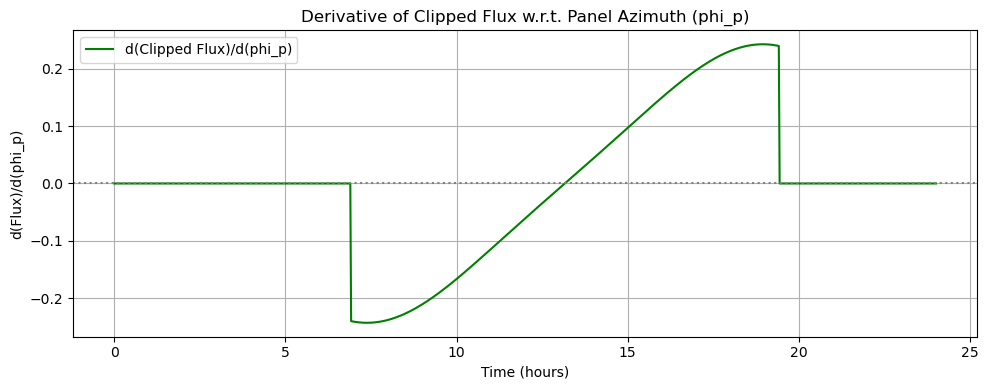

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define time vector in hours (0 to 24 hours)
t = np.linspace(0, 24, 1000)

# Constants
M = 79.38
A = -33.93
T = 13.17
w = 2 * np.pi / 24

# Solar angles as functions of time
theta_sol = np.deg2rad(M + A * np.cos(w * (t - T)))  # solar elevation
phi_sol = np.deg2rad(16.73 * t - 40.17)  # solar azimuth

# Fixed panel angles
theta_panel = np.deg2rad(30)
phi_panel = np.deg2rad(180)

# Raw flux
raw_flux = 0.5 * (
    np.sin(theta_sol) * np.sin(theta_panel) * np.cos(phi_panel - phi_sol) +
    np.cos(theta_sol) * np.cos(theta_panel)
)

# Clipped flux (no negative values)
clipped_flux = np.maximum(raw_flux, 0)

# Derivative of raw flux w.r.t phi_p (analytical)
dflux_dphip = -0.5 * np.sin(theta_sol) * np.sin(theta_panel) * np.sin(phi_panel - phi_sol)

# Where raw flux < 0, clipped flux is flat (derivative = 0)
dflux_dphip_clipped = np.where(raw_flux < 0, 0, dflux_dphip)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(t, dflux_dphip_clipped, color='green', label="d(Clipped Flux)/d(phi_p)")
plt.axhline(0, color='gray', linestyle=':')
plt.title("Derivative of Clipped Flux w.r.t. Panel Azimuth (phi_p)")
plt.xlabel("Time (hours)")
plt.ylabel("d(Flux)/d(phi_p)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
